In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import glob


In [3]:
percent_identities = glob.glob("../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/*")
percent_identities

['../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/ARID3C',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/DMRTA2',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/REXO4',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/ZNF703',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/ZNF367',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/NR1H4',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/SMAD9',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/TBX4',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/ZNF358',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/FOXD4L5',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/ZNF536',
 '../data/zoonomia_toga_mca_all_TFs/prot_alignm

In [4]:
genes = []
avg_percent_identities = []

for path in percent_identities:
    genes.append(path.split("/")[-1])
    df = pd.read_csv(path)
    avg_percent_identities.append(df["percent_identity"].mean())
    
result_df = pd.DataFrame({"gene": genes, "avg_percent_identity": avg_percent_identities})
result_df

,gene,avg_percent_identity
0,ARID3C,84.970050
1,DMRTA2,93.768829
2,REXO4,68.817389
3,ZNF703,95.973833
4,ZNF367,77.596576
...,...,...
1200,MYBL1,91.813906
1201,JAZF1,93.319816
1202,ZFP92,68.154180
1203,DUXA,57.693101


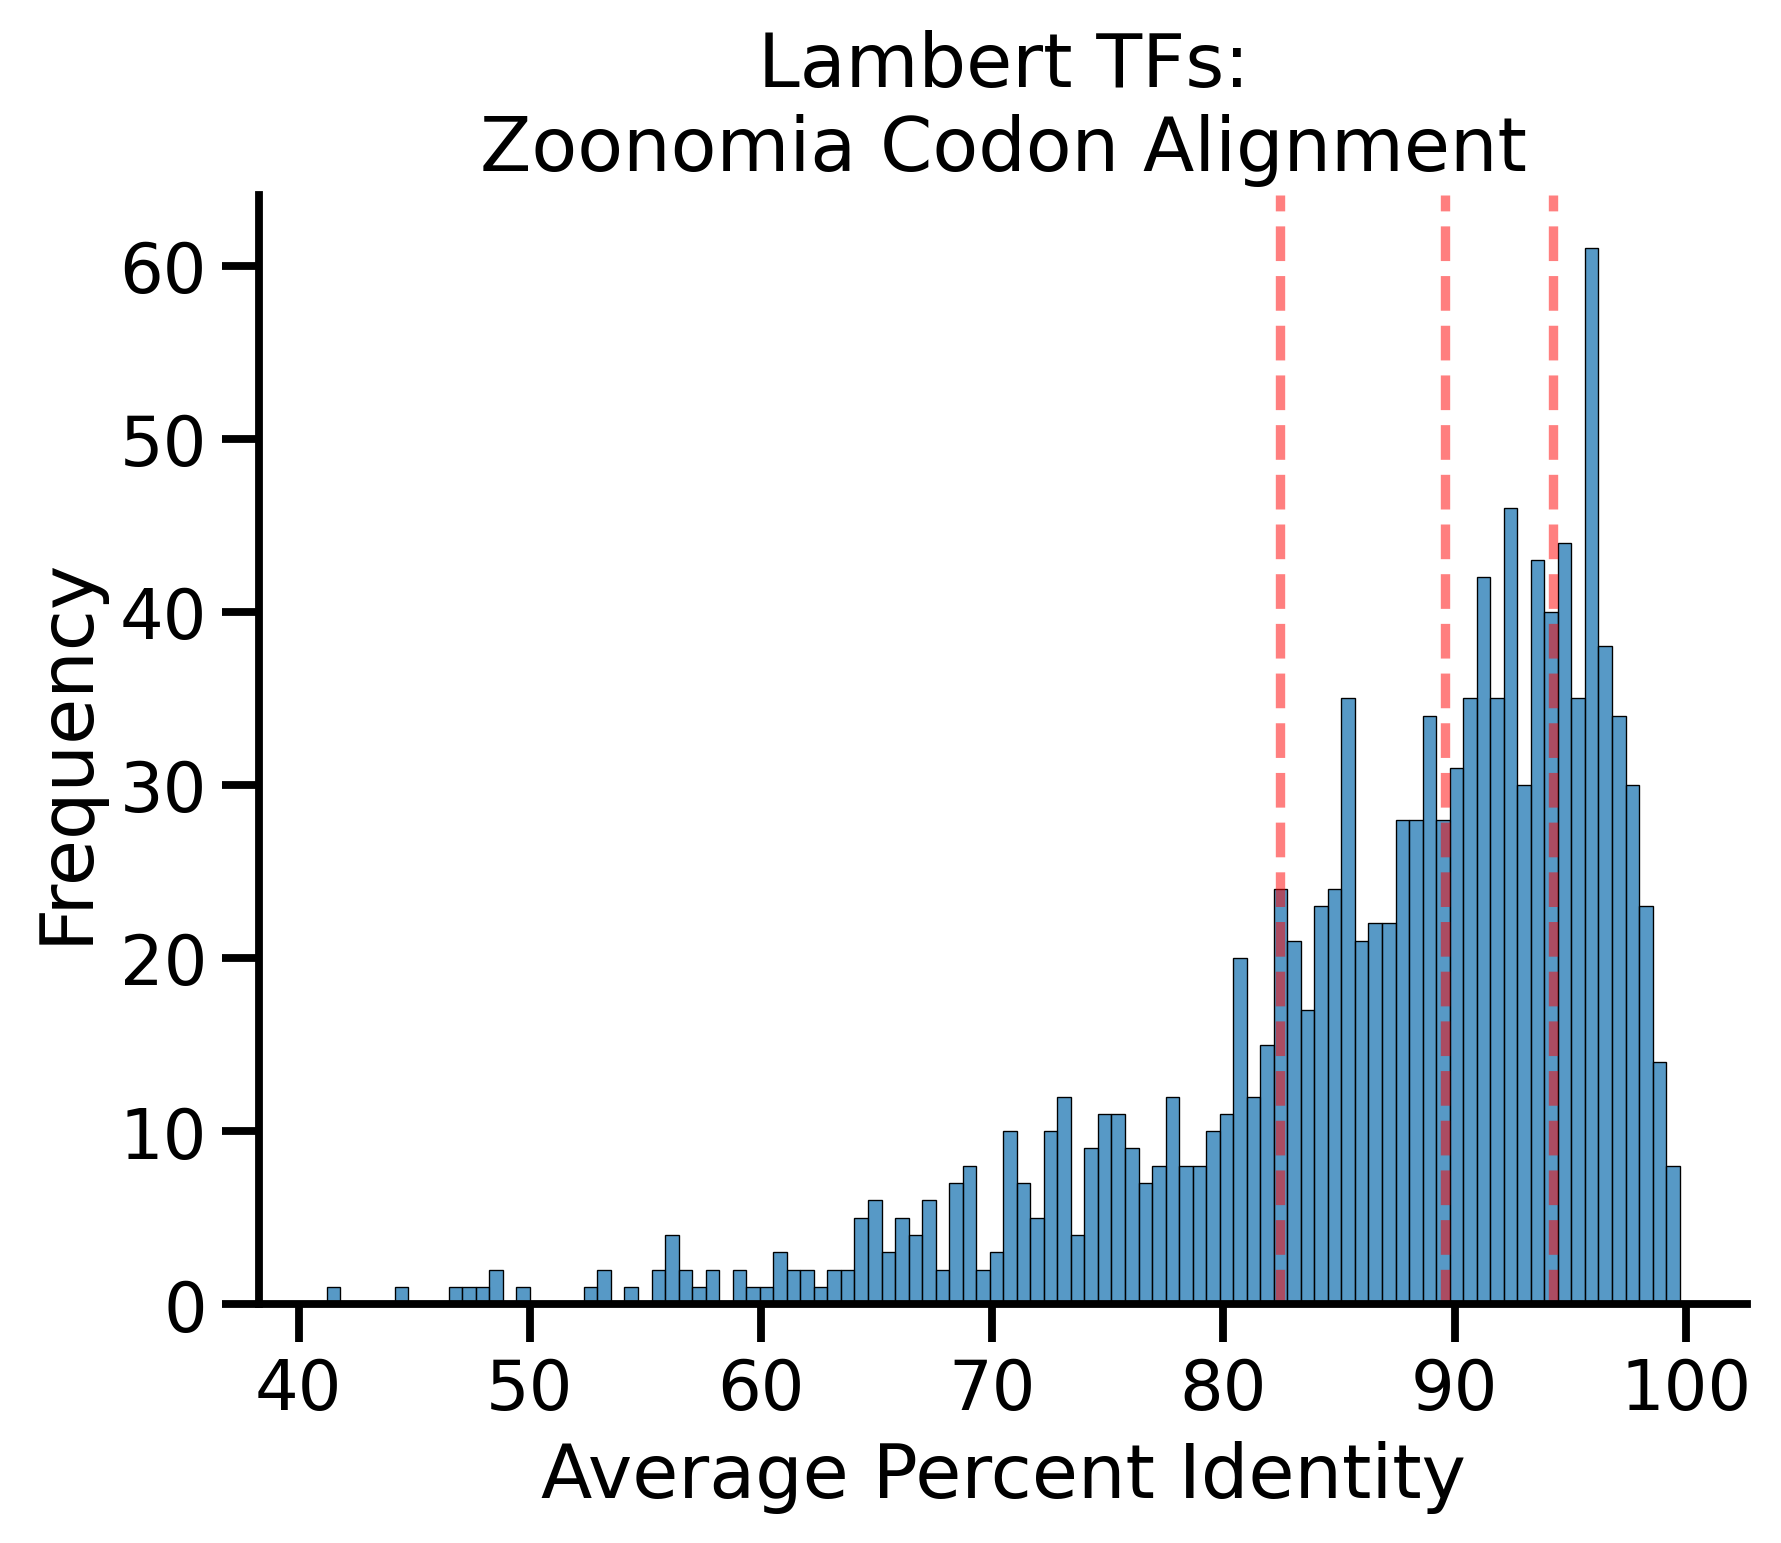

In [33]:
sns.set_context('talk')
plt.figure(dpi = 300)
ax = sns.histplot(result_df["avg_percent_identity"], bins = 100)

for percentile in np.arange(25, 100, 25):
    ax.axvline(np.percentile(result_df["avg_percent_identity"], percentile), color='red', linestyle = 'dashed', alpha = 0.5)

plt.title("Lambert TFs:\nZoonomia Codon Alignment")
plt.xlabel("Average Percent Identity")
plt.ylabel("Frequency")
sns.despine()

In [6]:
result_df.sort_values(by="avg_percent_identity")

,gene,avg_percent_identity
1178,NANOGNB,41.220347
880,LEUTX,44.639906
893,SOHLH1,46.566615
452,ZNF114,47.099737
1182,ZSCAN5C,47.889523
...,...,...
795,ZBTB14,99.407039
245,HAND2,99.446118
729,FOXB1,99.495385
380,ZNF664,99.567803


In [10]:
lambert_TFs = pd.read_csv("../output/lambert_TFs_10-21-24_with_DBD_coords.csv")
lambert_TFs["uniprotID"] = lambert_TFs["id"].str.split("|").str[1]
lambert_TFs

,Unnamed: 0,id,ProteinSeq,DBD_coords_merged,uniprotID
0,0,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEA...,"[[221, 243], [249, 271], [277, 299], [305, 327...",A0A087WUV0
1,1,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,"[[114, 182], [262, 347]]",A0AVK6
2,2,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,"[[260, 282], [288, 310], [316, 338], [344, 366...",A0PJY2
3,3,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,"[[1, 330]]",A1A519
4,4,sp|A1YPR0|ZBT7C_HUMAN Zinc finger and BTB doma...,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,"[[364, 386], [392, 414], [420, 442], [448, 469]]",A1YPR0
...,...,...,...,...,...
1608,1608,sp|Q9Y6Q9|NCOA3_HUMAN Nuclear receptor coactiv...,MSGLGENLDPLASDSRKRKLPCDTPGQGLTCSGEKRRREQESKYIE...,"[[31, 83]]",Q9Y6Q9
1609,1609,sp|Q9Y6R6|Z780B_HUMAN Zinc finger protein 780B...,MVHGSVTFRDVAIDFSQEEWECLQPDQRTLYRDVMLENYSHLISLG...,"[[165, 187], [193, 215], [221, 243], [249, 271...",Q9Y6R6
1610,1610,sp|Q9Y6X0|SETBP_HUMAN SET-binding protein OS=H...,MESRETLSSSRQRGGESDFLPVSSAKPPAAPGCAGEPLLSTPGPGK...,"[[583, 596], [1015, 1027], [1450, 1462]]",Q9Y6X0
1611,1611,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...,"[[78, 101], [110, 133], [271, 317], [442, 496]...",Q9Y6X8


In [24]:
# Loading in the table of ensembl matches
ensembl_matches = pd.read_csv("../data/TF_uniprotIDs_to_ENST_gene.tsv", sep = "\t")
ensembl_matches["gene"] = ensembl_matches["Gene Names"].str.split(" ").str[0]
exploded_genes = ensembl_matches.explode("gene")
gene_to_uniprot = dict(zip(exploded_genes["gene"], exploded_genes["Entry"]))
gene_to_uniprot

{'ZNF892': 'A0A087WUV0',
 'E2F8': 'A0AVK6',
 'FEZF1': 'A0PJY2',
 'FAM170A': 'A1A519',
 'ZBTB7C': 'A1YPR0',
 'ZNF320': 'A2RRD8',
 'HMX2': 'A2RU54',
 'ZNF804B': 'A4D1E1',
 'NKX2-6': 'A6NCS4',
 'HELT': 'A6NFD8',
 'ZNF316': 'A6NFI3',
 'DPRX': 'A6NFQ7',
 'ZSCAN5C': 'A6NGD5',
 'ZNF860': 'A6NHJ4',
 'HMX3': 'A6NHT5',
 'MSGN1': 'A6NI15',
 'NKX6-3': 'A6NJ46',
 'ARGFX': 'A6NJG6',
 'ZSCAN5B': 'A6NJL1',
 'UNCX': 'A6NJT0',
 'ZNF233': 'A6NK53',
 'ZNF98': 'A6NK75',
 'ARID3C': 'A6NKF2',
 'DUXA': 'A6NLW8',
 'ZFP92': 'A6NM28',
 'DBX1': 'A6NMT0',
 'ZNF729': 'A6NN14',
 'DRGX': 'A6NNA5',
 'ZNF726': 'A6NNF4',
 'ZNF716': 'A6NP11',
 'ZNF785': 'A8K8V0',
 'ZNF850': 'A8MQ14',
 'ZNF891': 'A8MT65',
 'CENPX': 'A8MT69',
 'FOXI3': 'A8MTJ6',
 'NOTO': 'A8MTQ0',
 'ZNF724': 'A8MTY0',
 'ZNF727': 'A8MUV8',
 'ZNF705G': 'A8MUZ8',
 'ZNF99': 'A8MXY4',
 'FOXO6': 'A8MYZ6',
 'LEUTX': 'A8MZ59',
 'ZNF487': 'B1APH4',
 'ZBTB42': 'B2RXF5',
 'ZNF879': 'B4DU55',
 'ZNF736': 'B4DX44',
 'ZNF732': 'B4DXR9',
 'ZNF814': 'B7Z6K7',
 'ZFTA': 'C9J

In [25]:
result_df["uniprotID"] = result_df["gene"].map(gene_to_uniprot)
result_df

,gene,avg_percent_identity,uniprotID,quartile
0,ARID3C,84.970050,A6NKF2,2
1,DMRTA2,93.768829,Q96SC8,3
2,REXO4,68.817389,Q9GZR2,1
3,ZNF703,95.973833,Q9H7S9,4
4,ZNF367,77.596576,Q7RTV3,1
...,...,...,...,...
1200,MYBL1,91.813906,P10243,3
1201,JAZF1,93.319816,Q86VZ6,3
1202,ZFP92,68.154180,A6NM28,1
1203,DUXA,57.693101,A6NLW8,1


In [26]:
result_df["quartile"] = pd.qcut(result_df["avg_percent_identity"], q=4, labels=False) + 1
result_df.drop_duplicates()

,gene,avg_percent_identity,uniprotID,quartile
0,ARID3C,84.970050,A6NKF2,2
1,DMRTA2,93.768829,Q96SC8,3
2,REXO4,68.817389,Q9GZR2,1
3,ZNF703,95.973833,Q9H7S9,4
4,ZNF367,77.596576,Q7RTV3,1
...,...,...,...,...
1200,MYBL1,91.813906,P10243,3
1201,JAZF1,93.319816,Q86VZ6,3
1202,ZFP92,68.154180,A6NM28,1
1203,DUXA,57.693101,A6NLW8,1


In [27]:
merged_df = pd.merge(lambert_TFs, result_df, on = "uniprotID", how = "left").drop_duplicates()
merged_df

,Unnamed: 0,id,ProteinSeq,DBD_coords_merged,uniprotID,gene,avg_percent_identity,quartile
0,0,sp|A0A087WUV0|ZN892_HUMAN Zinc finger protein ...,MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEA...,"[[221, 243], [249, 271], [277, 299], [305, 327...",A0A087WUV0,NaN,NaN,NaN
1,1,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,MENEKENLFCEPHKRGLMKTPLKESTTANIVLAEIQPDFGPLTTPT...,"[[114, 182], [262, 347]]",A0AVK6,E2F8,87.570420,2.0
2,2,sp|A0PJY2|FEZF1_HUMAN Fez family zinc finger p...,MDSSCHNATTKMLATAPARGNMMSTSKPLAFSIERIMARTPEPKAL...,"[[260, 282], [288, 310], [316, 338], [344, 366...",A0PJY2,FEZF1,93.843589,3.0
3,3,sp|A1A519|F170A_HUMAN Protein FAM170A OS=Homo ...,MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,"[[1, 330]]",A1A519,FAM170A,74.175157,1.0
4,4,sp|A1YPR0|ZBT7C_HUMAN Zinc finger and BTB doma...,MANDIDELIGIPFPNHSSEVLCSLNEQRHDGLLCDVLLVVQEQEYR...,"[[364, 386], [392, 414], [420, 442], [448, 469]]",A1YPR0,ZBTB7C,93.508061,3.0
...,...,...,...,...,...,...,...,...
1608,1608,sp|Q9Y6Q9|NCOA3_HUMAN Nuclear receptor coactiv...,MSGLGENLDPLASDSRKRKLPCDTPGQGLTCSGEKRRREQESKYIE...,"[[31, 83]]",Q9Y6Q9,NCOA3,88.062246,2.0
1609,1609,sp|Q9Y6R6|Z780B_HUMAN Zinc finger protein 780B...,MVHGSVTFRDVAIDFSQEEWECLQPDQRTLYRDVMLENYSHLISLG...,"[[165, 187], [193, 215], [221, 243], [249, 271...",Q9Y6R6,NaN,NaN,NaN
1610,1610,sp|Q9Y6X0|SETBP_HUMAN SET-binding protein OS=H...,MESRETLSSSRQRGGESDFLPVSSAKPPAAPGCAGEPLLSTPGPGK...,"[[583, 596], [1015, 1027], [1450, 1462]]",Q9Y6X0,SETBP1,90.417720,3.0
1611,1611,sp|Q9Y6X8|ZHX2_HUMAN Zinc fingers and homeobox...,MASKRKSTTPCMVRTSQVVEQDVPEEVDRAKEKGIGTPQPDVAKDS...,"[[78, 101], [110, 133], [271, 317], [442, 496]...",Q9Y6X8,ZHX2,91.015049,3.0


In [30]:
merged_df["quartile"].value_counts()

quartile
1.0    299
2.0    298
3.0    298
4.0    294
Name: count, dtype: int64

In [31]:
merged_df.to_csv("../output/lambert_TFs_10-21-24_with_DBD_coords_conservation.csv")